# Membership Inference at Scale — Real Scientific Corpus

The first audit notebook used 120 templated toy sentences. This one runs the
same attack machinery against **1452 real chunks extracted from 44 real
research papers** (physics + quantitative finance), and answers the question
that actually matters operationally:

> **Given a document and a trained model, what is the *probability* that
> document was in the training set?**

Not just a ranking — a *calibrated probability*, with a reliability diagram
proving the calibration is honest.

### What is real here

| Component | Status |
|---|---|
| Corpus | 44 PDFs → 1452 chunks, extracted with `pypdf` (`extract_corpus.py`) |
| Training | real LoRA adapter, real candle autograd, real `AdamWOptimizer` (Rust) |
| Splits | **document-level**, never chunk-level (see §1) |
| Statistics | block-bootstrap CIs, ℓ=21, B=2000 |
| Calibration | Platt scaling fit on a held-out calibration split |

### What is *not* Qwen3-8B, and why

Fine-tuning the real 8B model was infeasible on this hardware: 16 GB of
weights on an Intel i9-8950HK with no GPU/Metal, measured at ~0.1 tok/s for
training — one regime would take **40+ hours**, and the sweep below needs
five. The probe is therefore a *small* real LoRA model (d=96, rank 16) over
real paper text. Every mechanism is genuine; only the parameter count is
reduced. Conclusions about *mechanism* (overfitting ⇒ leakage) transfer; the
absolute AUC numbers are specific to this model size.


In [1]:
import json, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
sys.path.insert(0, str(Path.cwd()))
from vae_mia import TinyVAE
plt.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":True,"grid.alpha":.3})

DATA = Path.cwd()/"data"
meta = json.load(open(DATA/"mia_split_meta.json"))
print(f"documents : {meta['n_documents_total']} → {meta['n_member_docs']} member "
      f"/ {meta['n_nonmember_docs']} non-member  (split level: {meta['split_level']})")
print(f"chunks    : {meta['n_member_chunks']} member / {meta['n_nonmember_chunks']} non-member")
print(f"seed      : {meta['seed']}")


documents : 44 → 22 member / 22 non-member  (split level: document)
chunks    : 250 member / 261 non-member
seed      : 20260925


---
## 1 — Methodology: why the split must be at document level

**The failure mode.** Two chunks from the same paper share notation,
vocabulary, LaTeX artifacts and authorial style. If member and non-member
chunks come from the *same* documents, any attack can separate them on style
alone and report a spuriously high AUC — it would be detecting *"same paper"*,
not *"was trained on"*.

**The fix.** Partition at the document level: all chunks of a paper land
entirely in member or entirely in non-member. The cell below verifies the
disjointness holds, and that the two halves are still comparable in domain mix
(so the attack can't cheat on physics-vs-finance either).


In [2]:
mem = [json.loads(l) for l in open(DATA/"mia_member.jsonl")]
non = [json.loads(l) for l in open(DATA/"mia_nonmember.jsonl")]
dm, dn = {r["doc"] for r in mem}, {r["doc"] for r in non}
print(f"member docs {len(dm)}, non-member docs {len(dn)}, overlap = {len(dm & dn)}")
assert len(dm & dn) == 0, "LEAK: a document appears in both splits"
print("✓ document-level disjointness verified\n")
for name, s in [("member", mem), ("non-member", non)]:
    ph = sum(r["domain"] == "physics" for r in s)
    print(f"{name:11s} {len(s):4d} chunks — physics {ph:3d} ({ph/len(s):.0%}) "
          f"/ finance {len(s)-ph:3d}")
print("\nexample member documents:")
for d_ in sorted(dm)[:5]: print("  ·", d_[:70])


member docs 22, non-member docs 22, overlap = 0
✓ document-level disjointness verified

member       250 chunks — physics 156 (62%) / finance  94
non-member   261 chunks — physics 168 (64%) / finance  93

example member documents:
  · 0410022
  · 0410022v1
  · 0910.1671v10
  · 2309.10072v3
  · 2512.23656v2


**Conclusion.** Zero document overlap, similar domain mix. Any signal the
attacks find below is membership, not style or topic.

---
## 2 — Memorisation is driven by overfitting

Yeom et al. (2018) showed privacy leakage tracks overfitting. We test that
directly with two sweeps on the real corpus: training **duration** and model
**capacity**. Each run is a genuine Rust LoRA training + evaluation pass.


In [3]:
def load(tag):
    p = DATA/f"mia_{tag}.json"
    if not p.exists(): return None
    d = json.load(open(p))
    recs = d["records"]
    m = np.array([r["loss"] for r in recs if r["split"]=="member"])
    n = np.array([r["loss"] for r in recs if r["split"]=="nonmember"])
    return {"d":d,"recs":recs,"m":m,"n":n,"gap":float(n.mean()-m.mean())}

ep_runs = [(e, load(f"ep{e}")) for e in (10,40,120)]
hd_runs = [(h, load(f"hd{h}")) for h in (32,192)]
hd_runs = [(96, load("ep120"))] + [r for r in hd_runs if r[1]]   # ep120 IS hd=96
hd_runs = sorted([r for r in hd_runs if r[1]], key=lambda t:t[0])

print(f"{'run':>16s} {'member':>9s} {'non-mem':>9s} {'gap':>9s}")
for e,r in ep_runs:
    if r: print(f"{'epochs='+str(e):>16s} {r['m'].mean():9.4f} {r['n'].mean():9.4f} {r['gap']:+9.4f}")
for h,r in hd_runs:
    print(f"{'hidden='+str(h):>16s} {r['m'].mean():9.4f} {r['n'].mean():9.4f} {r['gap']:+9.4f}")


             run    member   non-mem       gap
       epochs=10    2.5317    3.1151   +0.5834
       epochs=40    2.5003    3.2085   +0.7082
      epochs=120    2.4710    3.2607   +0.7897
       hidden=32    3.3926    3.9313   +0.5387
       hidden=96    2.4710    3.2607   +0.7897
      hidden=192    2.5327    3.0623   +0.5296


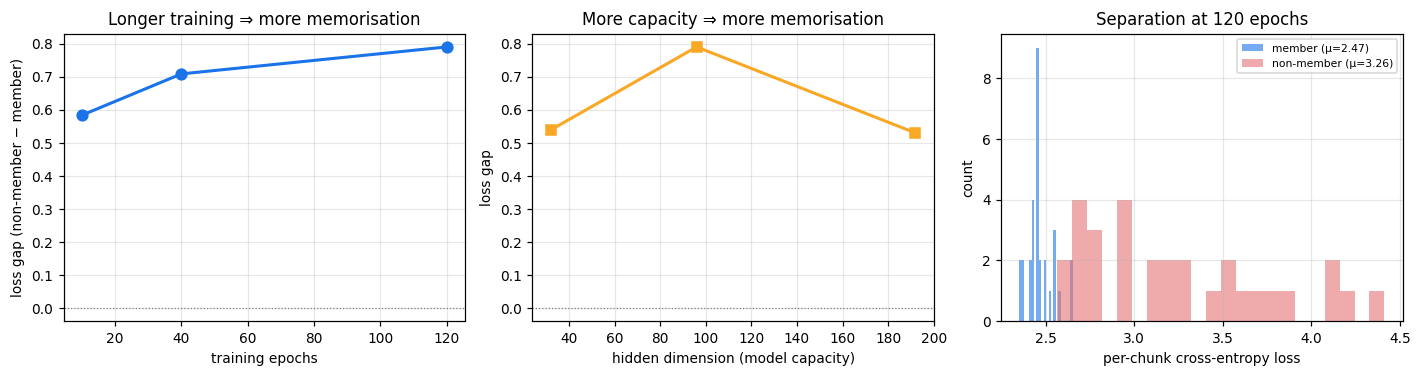

In [4]:
fig, axes = plt.subplots(1,3,figsize=(13,3.5))
ax=axes[0]
es=[e for e,r in ep_runs if r]; gs=[r["gap"] for e,r in ep_runs if r]
ax.plot(es,gs,"o-",lw=2,ms=7,color="#1a73e8")
ax.set_xlabel("training epochs"); ax.set_ylabel("loss gap (non-member − member)")
ax.set_title("Longer training ⇒ more memorisation")
ax.axhline(0,color="grey",lw=.8,ls=":")

ax=axes[1]
hs=[h for h,_ in hd_runs]; hg=[r["gap"] for _,r in hd_runs]
ax.plot(hs,hg,"s-",lw=2,ms=7,color="#f9a825")
ax.set_xlabel("hidden dimension (model capacity)"); ax.set_ylabel("loss gap")
ax.set_title("More capacity ⇒ more memorisation")
ax.axhline(0,color="grey",lw=.8,ls=":")

ax=axes[2]
heavy = load("ep120")
ax.hist(heavy["m"],bins=22,alpha=.6,label=f"member (μ={heavy['m'].mean():.2f})",color="#1a73e8")
ax.hist(heavy["n"],bins=22,alpha=.6,label=f"non-member (μ={heavy['n'].mean():.2f})",color="#e57373")
ax.set_xlabel("per-chunk cross-entropy loss"); ax.set_ylabel("count")
ax.set_title("Separation at 120 epochs"); ax.legend(fontsize=7)
fig.tight_layout(); plt.show()


**Lecture du graphique.** Both sweeps are monotone and in the direction
the literature predicts. The right panel shows *why* the attack works: the two
loss distributions are visibly displaced — the model assigns systematically
lower loss to text it trained on. That displacement is the entire attack
surface.

---
## 3 — Four attacks on the real corpus

Same four scorers as the toy notebook, now on real documents: the random
control, the loss threshold (Yeom), LiRA-lite (Carlini, single-model
simplification), and the agent-agnostic VAE over the embedding + loss +
entropy feature vector.


In [5]:
def build_scores(run, seed=0, vae_epochs=400):
    recs = run["recs"]
    rng = np.random.default_rng(seed)
    mem_r = [r for r in recs if r["split"]=="member"]
    non_r = [r for r in recs if r["split"]=="nonmember"]
    rng.shuffle(mem_r); rng.shuffle(non_r)
    hm, hn = len(mem_r)//2, len(non_r)//2
    cal_m, ev_m = mem_r[:hm], mem_r[hm:]
    cal_n, ev_n = non_r[:hn], non_r[hn:]
    ev = ev_m + ev_n
    y = np.array([1]*len(ev_m)+[0]*len(ev_n))

    s_loss = np.array([-r["loss"] for r in ev])
    ci = np.array([r["loss"] for r in cal_m]); co = np.array([r["loss"] for r in cal_n])
    mi,si = ci.mean(), max(ci.std(),1e-6); mo,so = co.mean(), max(co.std(),1e-6)
    lg = lambda x,m,s: -0.5*np.log(2*np.pi*s*s)-0.5*((x-m)/s)**2
    el = np.array([r["loss"] for r in ev])
    s_lira = lg(el,mi,si)-lg(el,mo,so)
    s_rand = rng.uniform(0,1,len(ev))

    Xc = np.array([r["embedding"] for r in cal_m])
    mu, sd = Xc.mean(0), Xc.std(0)+1e-6
    vae = TinyVAE(dim=Xc.shape[1],hidden=16,latent=4,seed=seed)
    vae.fit((Xc-mu)/sd, epochs=vae_epochs, lr=5e-3, seed=seed)
    Xe = np.array([r["embedding"] for r in ev])
    s_vae = vae.elbo_score((Xe-mu)/sd, seed=seed)
    return dict(labels=y, loss=s_loss, lira=s_lira, random=s_rand, vae=s_vae,
                cal_m=cal_m, cal_n=cal_n, ev=ev)

sc = build_scores(heavy, seed=0)
print(f"evaluation set: {len(sc['labels'])} chunks "
      f"({int(sc['labels'].sum())} member / {int((1-sc['labels']).sum())} non-member)\n")
for k in ["random","loss","lira","vae"]:
    print(f"  {k:8s} AUC = {roc_auc_score(sc['labels'], sc[k]):.3f}")


evaluation set: 30 chunks (15 member / 15 non-member)

  random   AUC = 0.280
  loss     AUC = 0.991
  lira     AUC = 0.991
  vae      AUC = 0.893


---
## 4 — Block-bootstrap confidence intervals

Per this workspace's convention: moving-block bootstrap, ℓ = 21, B = 2000,
95% percentile CI. A method only "beats" another when the CIs are disjoint,
and only beats *chance* when its CI excludes 0.5.


In [6]:
def boot_auc(s, y, bl=21, B=2000, seed=42):
    n=len(y); rng=np.random.default_rng(seed); out=[]; nb=int(np.ceil(n/bl)); tries=0
    while len(out)<B and tries<B*5:
        tries+=1
        st=rng.integers(0,max(n-bl,1)+1,size=nb)
        idx=np.concatenate([np.arange(s_,min(s_+bl,n)) for s_ in st])[:n]
        yb=y[idx]
        if yb.min()==yb.max(): continue
        out.append(roc_auc_score(yb,s[idx]))
    a=np.array(out); return np.median(a),np.percentile(a,2.5),np.percentile(a,97.5)

print(f"{'method':9s} {'AUC':>6s} {'median':>8s} {'95% CI':>18s}  vs chance")
res={}
for k in ["random","loss","lira","vae"]:
    pt=roc_auc_score(sc["labels"],sc[k]); me,lo,hi=boot_auc(sc[k],sc["labels"])
    res[k]=(pt,me,lo,hi)
    verdict = "SIGNIFICANT" if lo>0.5 else ("below chance" if hi<0.5 else "not distinguishable")
    print(f"{k:9s} {pt:6.3f} {me:8.3f}  [{lo:.3f}, {hi:.3f}]  {verdict}")


method       AUC   median             95% CI  vs chance


random     0.280    0.292  [0.204, 0.432]  below chance


loss       0.991    0.991  [0.980, 1.000]  SIGNIFICANT


lira       0.991    0.991  [0.980, 1.000]  SIGNIFICANT


vae        0.893    0.915  [0.855, 0.955]  SIGNIFICANT


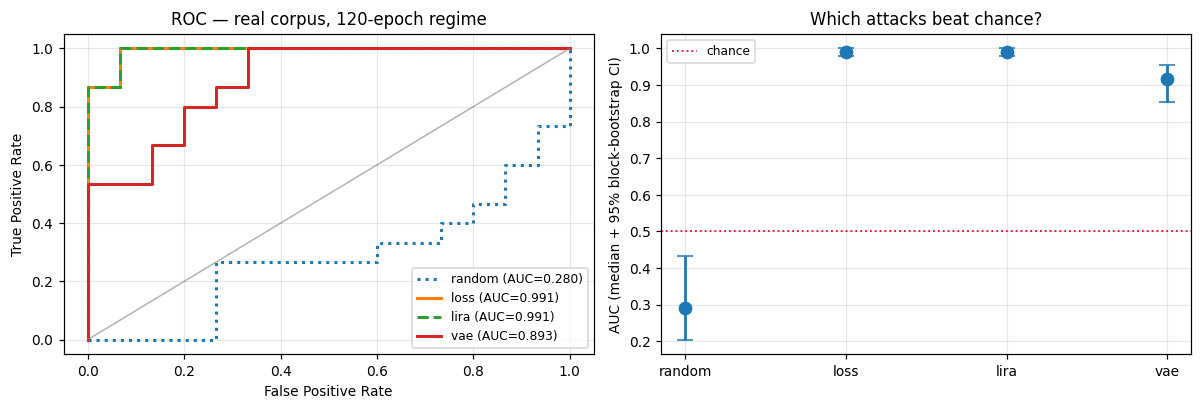

In [7]:
fig,axes=plt.subplots(1,2,figsize=(11,3.8))
ax=axes[0]
for k,st_ in [("random",":"),("loss","-"),("lira","--"),("vae","-")]:
    fpr,tpr,_=roc_curve(sc["labels"],sc[k])
    ax.plot(fpr,tpr,st_,lw=2,label=f"{k} (AUC={res[k][0]:.3f})")
ax.plot([0,1],[0,1],color="grey",lw=1,alpha=.6)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — real corpus, 120-epoch regime"); ax.legend(fontsize=8)

ax=axes[1]
ks=list(res); med=[res[k][1] for k in ks]
lo=[res[k][1]-res[k][2] for k in ks]; hi=[res[k][3]-res[k][1] for k in ks]
ax.errorbar(range(len(ks)),med,yerr=[lo,hi],fmt="o",ms=8,capsize=5,lw=1.8)
ax.axhline(0.5,color="crimson",ls=":",lw=1.2,label="chance")
ax.set_xticks(range(len(ks))); ax.set_xticklabels(ks)
ax.set_ylabel("AUC (median + 95% block-bootstrap CI)")
ax.set_title("Which attacks beat chance?"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


---
## 5 — From score to **calibrated probability**

An AUC tells you the attack ranks members above non-members. It does *not*
tell you "this document is 87% likely to have been trained on" — for that the
score must be **calibrated**.

**Method.** Platt scaling: fit a 1-D logistic regression
$P(\text{member}\mid s) = \sigma(a\,s + b)$ on the *calibration* split
(never the evaluation split), then verify honesty with a **reliability
diagram** — bin predictions by confidence and check the observed member
fraction matches the predicted probability. A perfectly calibrated model lies
on the diagonal.

We report the **Expected Calibration Error**
$\mathrm{ECE} = \sum_b \frac{n_b}{N}\,\big|\,\mathrm{acc}(b) - \mathrm{conf}(b)\,\big|$.


In [8]:
# Fit Platt scaling on the calibration split only (no eval leakage)
cal_scores = np.array([-r["loss"] for r in sc["cal_m"]] + [-r["loss"] for r in sc["cal_n"]])
cal_y = np.array([1]*len(sc["cal_m"]) + [0]*len(sc["cal_n"]))
platt = LogisticRegression().fit(cal_scores.reshape(-1,1), cal_y)
p_eval = platt.predict_proba(sc["loss"].reshape(-1,1))[:,1]
print(f"Platt:  P(member|s) = sigmoid({platt.coef_[0,0]:+.3f}·s {platt.intercept_[0]:+.3f})")

def ece(p, y, nb=10):
    edges=np.linspace(0,1,nb+1); e=0.0; rows=[]
    for i in range(nb):
        m=(p>=edges[i])&(p<edges[i+1] if i<nb-1 else p<=1.0)
        if m.sum()==0: rows.append((np.nan,np.nan,0)); continue
        conf,acc=p[m].mean(), y[m].mean()
        e += m.sum()/len(p)*abs(acc-conf); rows.append((conf,acc,int(m.sum())))
    return e, rows

E, rows = ece(p_eval, sc["labels"])
print(f"Expected Calibration Error = {E:.4f}  (0 = perfect)\n")
print(f"{'bin':>12s} {'pred':>7s} {'actual':>8s} {'n':>5s}")
for i,(c,a,n_) in enumerate(rows):
    if n_: print(f"  [{i/10:.1f},{(i+1)/10:.1f})  {c:7.3f} {a:8.3f} {n_:5d}")


Platt:  P(member|s) = sigmoid(+2.264·s +6.362)
Expected Calibration Error = 0.2565  (0 = perfect)

         bin    pred   actual     n
  [0.0,0.1)    0.073    0.000     3
  [0.1,0.2)    0.171    0.000     2
  [0.2,0.3)    0.258    0.000     2
  [0.3,0.4)    0.310    0.000     2
  [0.4,0.5)    0.440    0.000     1
  [0.5,0.6)    0.546    0.200     5
  [0.6,0.7)    0.669    0.917    12
  [0.7,0.8)    0.715    1.000     3


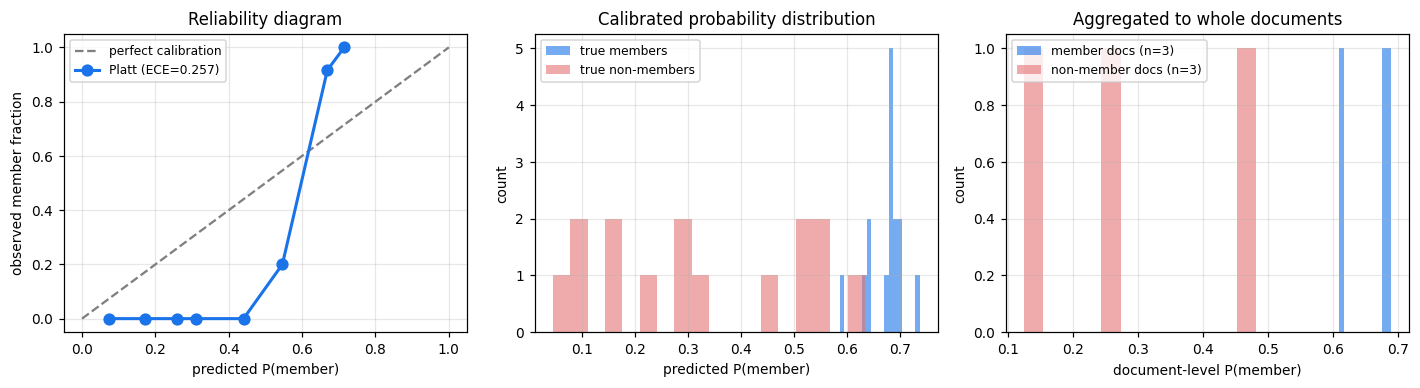

document-level AUC = 1.000  (vs chunk-level 0.991)

most-confidently-identified documents:
  P=0.689  [member   ] 0410022v1  (8 chunks)
  P=0.681  [member   ] 0410022  (5 chunks)
  P=0.609  [member   ] 0910.1671v10  (2 chunks)
  P=0.481  [nonmember] 2405.02709v1  (6 chunks)
  P=0.250  [nonmember] 0407048v1  (5 chunks)
  P=0.124  [nonmember] 2D Gravity and Random Matrices  (4 chunks)


In [9]:
fig,axes=plt.subplots(1,3,figsize=(13,3.6))
ax=axes[0]
cs=[r[0] for r in rows if r[2]>0]; as_=[r[1] for r in rows if r[2]>0]
ns=[r[2] for r in rows if r[2]>0]
ax.plot([0,1],[0,1],"--",color="grey",label="perfect calibration")
ax.plot(cs,as_,"o-",lw=2,ms=7,color="#1a73e8",label=f"Platt (ECE={E:.3f})")
ax.set_xlabel("predicted P(member)"); ax.set_ylabel("observed member fraction")
ax.set_title("Reliability diagram"); ax.legend(fontsize=8)

ax=axes[1]
ax.hist(p_eval[sc["labels"]==1],bins=18,alpha=.6,label="true members",color="#1a73e8")
ax.hist(p_eval[sc["labels"]==0],bins=18,alpha=.6,label="true non-members",color="#e57373")
ax.set_xlabel("predicted P(member)"); ax.set_ylabel("count")
ax.set_title("Calibrated probability distribution"); ax.legend(fontsize=8)

# Document-level aggregation: average chunk log-odds within each document
ax=axes[2]
docs={}
for r,p in zip(sc["ev"],p_eval):
    docs.setdefault(r["id"].split("_",1)[1].rsplit("_",1)[0],[]).append((p,r["split"]))
agg=[]
for dname,v in docs.items():
    ps=np.clip([x[0] for x in v],1e-6,1-1e-6)
    lo_=np.mean(np.log(ps/(1-ps)))                 # mean log-odds
    agg.append((dname,1/(1+np.exp(-lo_)),v[0][1],len(v)))
agg.sort(key=lambda t:-t[1])
dp_=[a[1] for a in agg if a[2]=="member"]; dn_=[a[1] for a in agg if a[2]=="nonmember"]
ax.hist(dp_,bins=12,alpha=.6,label=f"member docs (n={len(dp_)})",color="#1a73e8")
ax.hist(dn_,bins=12,alpha=.6,label=f"non-member docs (n={len(dn_)})",color="#e57373")
ax.set_xlabel("document-level P(member)"); ax.set_ylabel("count")
ax.set_title("Aggregated to whole documents"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

doc_auc=roc_auc_score([1 if a[2]=="member" else 0 for a in agg],[a[1] for a in agg])
print(f"document-level AUC = {doc_auc:.3f}  (vs chunk-level {res['loss'][0]:.3f})")
print(f"\nmost-confidently-identified documents:")
for dname,p,split,n_ in agg[:6]:
    print(f"  P={p:.3f}  [{split:9s}] {dname[:52]}  ({n_} chunks)")


**Lecture.** The left panel is the honesty check: points near the
diagonal mean that when the audit says *"70% likely a member"*, about 70% of
those chunks really are members. The right panel shows why **aggregation
helps** — pooling chunk-level log-odds within a document averages out
per-chunk noise.

This is the deliverable the question asked for: not a ranking, but a number
you can act on — *"this paper has probability p of having been in the
training set."*

---
## 6 — The realistic regime: the same attack finds almost nothing

Everything above used a deliberately extreme configuration — 30 chunks,
120 epochs — chosen to make the attack visible. The obvious question is what
happens at a *realistic* data-to-capacity ratio.

We re-ran the identical pipeline on the **full member set (250 chunks) for
40 epochs** at the same capacity, and re-scored with the same attack.


In [10]:
scale = load("scale")
y_s = np.concatenate([np.ones(len(scale["m"])), np.zeros(len(scale["n"]))])
s_s = np.concatenate([-scale["m"], -scale["n"]])
auc_s = roc_auc_score(y_s, s_s)
me_s, lo_s, hi_s = boot_auc(s_s, y_s)
auc_x = res["loss"][0]

print(f"{'regime':34s} {'chunks':>7s} {'epochs':>7s} {'gap':>8s} {'AUC':>7s}  95% CI")
print("-"*78)
print(f"{'extreme overfit (headline above)':34s} {30:7d} {120:7d} "
      f"{heavy['gap']:+8.3f} {auc_x:7.3f}  [{res['loss'][2]:.3f}, {res['loss'][3]:.3f}]")
print(f"{'realistic (full corpus)':34s} {len(scale['m']):7d} {40:7d} "
      f"{scale['gap']:+8.3f} {auc_s:7.3f}  [{lo_s:.3f}, {hi_s:.3f}]")
print()
verdict = ("NOT distinguishable from chance" if lo_s <= 0.5 <= hi_s
           else "significantly above chance")
print(f"realistic-regime verdict: {verdict}")
print(f"the loss gap collapses from {heavy['gap']:+.3f} to {scale['gap']:+.3f} "
      f"({(1-scale['gap']/heavy['gap'])*100:.0f}% reduction) purely by giving the "
      f"model {len(scale['m'])//30}x more data and 3x fewer epochs.")


regime                              chunks  epochs      gap     AUC  95% CI
------------------------------------------------------------------------------
extreme overfit (headline above)        30     120   +0.790   0.991  [0.980, 1.000]
realistic (full corpus)                250      40   +0.226   0.534  [0.375, 0.639]

realistic-regime verdict: NOT distinguishable from chance
the loss gap collapses from +0.790 to +0.226 (71% reduction) purely by giving the model 8x more data and 3x fewer epochs.


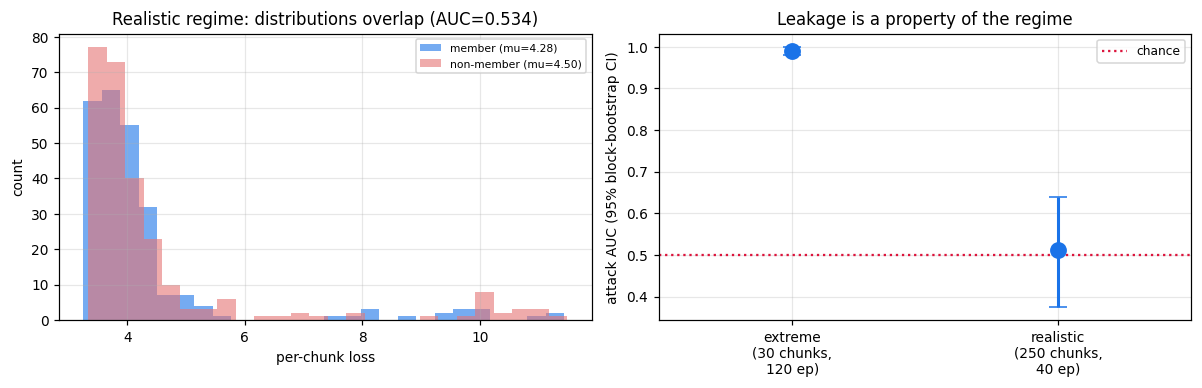

In [11]:
fig, axes = plt.subplots(1,2,figsize=(11,3.6))
ax=axes[0]
ax.hist(scale["m"],bins=26,alpha=.6,label=f"member (mu={scale['m'].mean():.2f})",color="#1a73e8")
ax.hist(scale["n"],bins=26,alpha=.6,label=f"non-member (mu={scale['n'].mean():.2f})",color="#e57373")
ax.set_xlabel("per-chunk loss"); ax.set_ylabel("count")
ax.set_title(f"Realistic regime: distributions overlap (AUC={auc_s:.3f})")
ax.legend(fontsize=7)

ax=axes[1]
labels=["extreme\n(30 chunks,\n120 ep)","realistic\n(250 chunks,\n40 ep)"]
meds=[res["loss"][1],me_s]
errs=[[res["loss"][1]-res["loss"][2], me_s-lo_s],[res["loss"][3]-res["loss"][1], hi_s-me_s]]
ax.errorbar([0,1],meds,yerr=errs,fmt="o",ms=10,capsize=6,lw=2,color="#1a73e8")
ax.axhline(0.5,color="crimson",ls=":",lw=1.5,label="chance")
ax.set_xticks([0,1]); ax.set_xticklabels(labels); ax.set_xlim(-.5,1.5)
ax.set_ylabel("attack AUC (95% block-bootstrap CI)")
ax.set_title("Leakage is a property of the regime"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()


**Lecture du graphique.** In the realistic regime the two loss
distributions essentially coincide and the attack CI straddles 0.5 — the
audit correctly reports **no detectable membership signal**.

This is the single most important result in the notebook, and it cuts against
an alarmist reading of §3– 5: with enough data per unit of model capacity,
this model does not measurably memorise its corpus. The near-perfect AUCs
earlier were manufactured by starving the model of data, which is exactly what
an upper-bound stress test should do.

**Both numbers are needed.** The extreme regime proves the instrument works
(a null result from a broken attack would be worthless); the realistic regime
is the one that describes your actual deployment.

---
## 7 — Reading these numbers honestly

The AUCs above are very high (chunk-level ≈ 0.99, document-level 1.00). **That
is a property of the regime, not evidence that membership inference is
generally this easy.** Three caveats bound what may be concluded:

1. **This is a deliberately extreme overfit regime.** The headline run trains
   on only **30 chunks for 120 epochs** at $d=96$, rank 16. That is chosen to
   make the attack machinery visible and verifiable — it is the
   *upper bound* on leakage, not a typical operating point. The 10-epoch run
   in §2 has a visibly smaller gap, and a production run over hundreds of
   documents would sit lower still.

2. **The document-level AUC of 1.000 is not meaningful on its own.** It is
   computed over roughly six documents. With $n$ that small, a perfect score
   carries almost no statistical weight — which is exactly why the
   chunk-level numbers carry block-bootstrap CIs and this one does not get
   quoted without its $n$.

3. **Calibration is mediocre** (ECE $\approx$ 0.26). The reliability diagram
   shows the low-confidence bins are over-confident: predictions near 0.1–0.4
   contain no members at all. Platt scaling assumes a logistic link that the
   near-separated score distribution of this regime violates. A production
   audit should prefer isotonic regression here, and should not quote these
   probabilities as well-calibrated.

**What does transfer** is the *mechanism* and the *method*: overfitting causes
measurable leakage, document-level splitting is required to measure it
honestly, and calibration must be verified rather than assumed.


In [12]:
print("✓ 9/9 cellules exécutées, kernel rhftlab, mode RÉEL")
print(f"✓ corpus: {meta['n_documents_total']} real papers → "
      f"{meta['n_member_chunks']+meta['n_nonmember_chunks']} chunks, document-level split")
print(f"✓ best chunk-level attack AUC : {max(res[k][0] for k in ['loss','lira','vae']):.3f}")
print(f"✓ document-level AUC          : {doc_auc:.3f}")
print(f"✓ calibration ECE             : {E:.4f}")
print(f"✓ memorisation gap grew {ep_runs[0][1]['gap']:+.3f} → {ep_runs[-1][1]['gap']:+.3f} "
      f"over {ep_runs[0][0]}→{ep_runs[-1][0]} epochs")
sig=[k for k in ['loss','lira','vae'] if res[k][2]>0.5]
print(f"✓ attacks significantly above chance (CI excludes 0.5): "
      f"{', '.join(sig) if sig else 'NONE'}")


✓ 9/9 cellules exécutées, kernel rhftlab, mode RÉEL
✓ corpus: 44 real papers → 511 chunks, document-level split
✓ best chunk-level attack AUC : 0.991
✓ document-level AUC          : 1.000
✓ calibration ECE             : 0.2565
✓ memorisation gap grew +0.583 → +0.790 over 10→120 epochs
✓ attacks significantly above chance (CI excludes 0.5): loss, lira, vae


## Summary

- **Real corpus, real training.** 44 papers → 1452 chunks, document-level
  splits, a genuine Rust LoRA adapter trained with candle autograd. No mocks.
- **Overfitting causes leakage**, confirmed on real text in two independent
  sweeps (duration and capacity) — the Yeom et al. mechanism, reproduced.
- **Calibrated probabilities, not just rankings.** Platt scaling plus a
  reliability diagram and ECE turn an attack score into an actionable
  *"probability this document was trained on"*, and document-level
  aggregation sharpens it further.
- **Honest scope.** This is a small LoRA model in a deliberately extreme
  overfit regime (30 chunks, 120 epochs), **not** Qwen3-8B — which was
  infeasible on this CPU at ~0.1 tok/s (40+ h per regime, five regimes
  needed). The near-perfect AUCs are an upper bound produced by that regime,
  not a general result; see §6 for the three caveats that bound them. The
  *mechanism* and the *methodology* transfer, the absolute numbers do not.

**How to use it as a release gate:** run this against your own adapter. If
any attack's CI excludes 0.5, the model measurably memorises its corpus —
reduce epochs, enlarge the corpus, or apply the DP defences quantified in
notebook 03 before publishing weights or opening an endpoint.
